# Final Exam (part 1) - Computational Physics 2

### Deadline: Wednesday 27 May 2026 (by 21h00)
### Credits: 10 points

### Please keep the structure provided below and submit an organised notebook with clear answers to each item.

## Name: Terry Cevallos

## 1. FFT method for fluid dynamics: 2D Shock waves (10 points)

We wish to study the emergence of 2D shock waves in fluids using a non-linear advection-diffusion equation. To do this we will modify our wave equation to account for non-linear convection in two dimensions. We will consider that the speed of an initial 2D Gaussian density perturbation $\rho(x, y, 0) = 4\,e^{-(x^2+y^2)}$ propagating across a periodic 2D domain is not constant, but a function of the density itself, so that our PDE becomes:

$$\frac{\partial \rho}{\partial t} + \rho\frac{\partial \rho}{\partial x} + \rho\frac{\partial \rho}{\partial y} = 0$$


As we see from the above equation, portions of $\rho$ with larger amplitudes will convect more rapidly, giving rise to wave steepening (i.e. to a discontinuity, which we call a **shock wave**). Without a diffusive term, the shock would become infinitely steep. Therefore, we add a diffusive (parabolic) term to our PDE so that the shock maintains a finite width. Our PDE then becomes:

$$\frac{\partial \rho}{\partial t} + \rho\frac{\partial \rho}{\partial x} + \rho\frac{\partial \rho}{\partial y} = \alpha\left(\frac{\partial^2 \rho}{\partial x^2} + \frac{\partial^2 \rho}{\partial y^2}\right)$$

where $\alpha$ is a diffusion constant.

Implement the following tasks using **python classes**:

#### Analytical Development:

**(a)**  Show analytically how spatial derivatives can be computed using the Fourier transform, as they will be needed later in the code. Specifically, if $\hat{\rho}(k_x, k_y, t) = \mathcal{F}\{\rho(x, y, t)\}$, write expressions for the Fourier transforms of the first-order derivatives ($\frac{\partial \rho}{\partial x}$, $\frac{\partial \rho}{\partial y}$) and the Laplacian ($\nabla^2\rho = \frac{\partial^2 \rho}{\partial x^2} + \frac{\partial^2 \rho}{\partial y^2}$) in terms of the wavenumbers $k_x$ and $k_y$. 

**F.T in space of $u_{x}(x,t)$:**
$$\frac{\partial u(x,t)}{\partial x} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial u}{\partial x} \right) = i k_x \ \hat{u}$$
**Then, by definition of F.T., the spatial derivative for px and py is:**
$$\mathcal{F}\left\{\frac{\partial \rho}{\partial x}\right\} = i k_x \hat{\rho}(k_x, k_y, t)$$
$$\mathcal{F}\left\{\frac{\partial \rho}{\partial y}\right\} = i k_y \hat{\rho}(k_x, k_y, t)$$
**F.T in space of $u_{xx}(x,t)$:**
$$\frac{\partial² u(x,t)}{\partial x²} \quad \Rightarrow \quad \mathcal{F} \left( \frac{\partial² u}{\partial x²} \right) = - (k_x)² \ \hat{u}$$
**In the case of the Laplacian, by definition of the FT, we obtain:**
$$\mathcal{F}\left\{\frac{\partial^2 \rho}{\partial x^2}\right\} = -k_x^2 \hat{\rho}(k_x, k_y, t)$$
$$\mathcal{F}\left\{\frac{\partial^2 \rho}{\partial y^2}\right\} = -k_y^2 \hat{\rho}(k_x, k_y, t)$$
$$\mathcal{F}\{\nabla^2\rho\} = \mathcal{F}\left\{\frac{\partial^2 \rho}{\partial x^2}\right\} + \mathcal{F}\left\{\frac{\partial^2 \rho}{\partial y^2}\right\} = -k_x^2 \hat{\rho} - k_y^2 \hat{\rho}$$


#### I added item (b) below to test my class and verify that it works correctly under the initial conditions, as well as item (d).


#### FFT Method:

**(c)** Write a method for the right-hand-side (RHS) of the PDE that allows you to map in and out of the Fourier domain at each time using 2D FFT. Note that this PDE is non-linear, so the function should return the RHS in real space. **Hint:** use your mathematical derivations from item (a) to evaluate the spatial derivatives.

```Python
class FluidDynamics:
    '''
    This class helps to solve PDE using FFT methods.
    The fluid dynamics is:
    drho/dt = alpha * (d^2 rho/dx^2 + d^2 rho/dy^2) - rho * (drho/dx + drho/dy)        
    '''

    def __init__(self, nx, ny, L, alpha):
        '''
        Initialize the class with the parameters of the problem.
        Inputs:
        - nx: number of grid points in x 
        - ny: number of grid points in y 
        - L: length of the domain 
        - alpha: diffusion coefficient 
        '''
        # Define parameters
        self.nx = nx
        self.ny = ny
        self.L = L
        self.alpha = alpha
        # Define step sizes 
        self.dx = L/nx
        self.dy = L/ny
        # Create axes
        self.x = np.linspace(- L/2, L/2 , self.nx, endpoint=False)
        self.y = np.linspace(-L/2, L/2 , self.ny, endpoint=False)
        # Ceated 2D grid
        self.x_2d, self.y_2d = np.meshgrid(self.x, self.y)
        # Define the intial condition
        self.rho_o = 4 * np.exp(-(self.x_2d**2 + self.y_2d**2))
        # Compute the Fourier space dimensions
        # Get spatial freequencies / wavenumbers
        self.kx = 2 * np.pi * np.fft.fftfreq(self.nx)/self.dx
        self.ky = 2 * np.pi * np.fft.fftfreq(self.ny)/self.dy
        # Create 2D grid of wavenumbers
        self.kx_2d, self.ky_2d = np.meshgrid(self.kx, self.ky)    

    def fft_derivative(self, rho):
        '''
        Compute the derivatives of rho in Fourier space.
        Inputs:
        - rho: density field
        Outputs:
        - dv_dx: first derivative of rho in x
        - dv_dy: first derivative of rho in y
        - dv_dx2: second derivative of rho in x
        - dv_dy2: second derivative of rho in y
        '''
        # rho in Fourier space
        rho_fft = np.fft.fft2(rho)
        # Apply FFT to the first derivative
        dv_dx = np.fft.ifft2(1j * self.kx_2d * rho_fft).real
        dv_dy = np.fft.ifft2(1j * self.ky_2d * rho_fft).real
        # Apply FFT to the second derivative
        dv_dx2 = np.fft.ifft2(-self.kx_2d**2 * rho_fft).real
        dv_dy2 = np.fft.ifft2(-self.ky_2d**2 * rho_fft).real

        return dv_dx, dv_dy, dv_dx2, dv_dy2     

    def rhs_fluid(self, t, rho):
        ''' 
        Compute the right-hand side of the fluid dynamics equation.
        Inputs:
        - t: time
        - rho: density field
        Outputs:
        - rhs: right-hand side 
        '''
        
        # Reshape rho to 2D
        rho_2d = rho.reshape(self.ny, self.nx)
        # Call the function to compute the derivatives
        dv_dx, dv_dy, dv_dx2, dv_dy2 = self.fft_derivative(rho_2d)
        # RHS of the diffusion equation
        rhs = self.alpha * (dv_dx2 + dv_dy2) - rho_2d * (dv_dx + dv_dy)
        rhs_1D = rhs.flatten() 
        return rhs_1D 

```



**(e)** Find and plot the solution, $\rho(x,y,t)$, **using your FFT method**. For this, you need to feed a scipy ODE integrator with the function you created in (c). **Hint:** make sure you construct and use the correct 2D wavenumber grids ($k_x$ and $k_y$). Note that standard ODE solvers require a 1D state vector, so you will need to flatten your 2D grid when feeding it to the integrator and reshape it inside your RHS function.

$$\frac{\partial \rho}{\partial t} = \alpha\left(\frac{\partial^2 \rho}{\partial x^2} + \frac{\partial^2 \rho}{\partial y^2}\right) - \rho\frac{\partial \rho}{\partial x} + \rho\frac{\partial \rho}{\partial y}$$

```Python
    def scipy_integrate(self, t_max, dt):       
        ''' 
        This function Integrate the fluid dynamics equation.
        Inputs:
        - t_max: maximum time
        - dt: time step
        Outputs:
        - final_solution: solution at each time step
        '''
        # Define time array
        t_eval = np.arange(0, t_max, dt)        
        # Get ICs 1D
        #self.rho_t[0] = self.rho_o
        # Time integration using solve_ivp    
        fluid_sln = sc.integrate.solve_ivp(self.rhs_fluid, [t_eval[0], t_eval[-1]], self.rho_o.flatten(), t_eval=t_eval, method='RK45')
        self.t = fluid_sln.t
        # Create an array to store the solution at each time step
        self.rho_t = np.zeros((len(self.t), self.ny, self.nx))
        # Loop over the time
        for i in range(len(self.t)):
            self.rho_t[i] = fluid_sln.y[:, i].reshape(self.ny, self.nx)
            final_solution = self.rho_t

        return final_solution

```

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy as sc
import os
import glob
from IPython.display import display, Image as Img
from PIL import Image

In [2]:
class FluidDynamics:
    '''
    This class helps to solve PDE using FFT methods.
    The fluid dynamics is:
    drho/dt = alpha * (d^2 rho/dx^2 + d^2 rho/dy^2) - rho * (drho/dx + drho/dy)        
    '''

    def __init__(self, nx, ny, L, alpha):
        '''
        Initialize the class with the parameters of the problem.
        Inputs:
        - nx: number of grid points in x 
        - ny: number of grid points in y 
        - L: length of the domain 
        - alpha: diffusion coefficient 
        '''
        # Define parameters
        self.nx = nx
        self.ny = ny
        self.L = L
        self.alpha = alpha
        # Define step sizes 
        self.dx = L/nx
        self.dy = L/ny
        # Create axes
        self.x = np.linspace(-L/2, L/2 , self.nx, endpoint=False)
        self.y = np.linspace(-L/2, L/2 , self.ny, endpoint=False)
        # Ceated 2D grid
        self.x_2d, self.y_2d = np.meshgrid(self.x, self.y)
        # Define the intial condition
        self.rho_o = 4 * np.exp(-(self.x_2d**2 + self.y_2d**2))
        # Compute the Fourier space dimensions
        # Get spatial freequencies / wavenumbers
        self.kx = 2 * np.pi * np.fft.fftfreq(self.nx)/self.dx
        self.ky = 2 * np.pi * np.fft.fftfreq(self.ny)/self.dy
        # Create 2D grid of wavenumbers
        self.kx_2d, self.ky_2d = np.meshgrid(self.kx, self.ky)    

    def fft_derivative(self, rho):
        '''
        Compute the derivatives of rho in Fourier space.
        Inputs:
        - rho: density field
        Outputs:
        - dv_dx: first derivative of rho in x
        - dv_dy: first derivative of rho in y
        - dv_dx2: second derivative of rho in x
        - dv_dy2: second derivative of rho in y
        '''
        # rho in Fourier space
        rho_fft = np.fft.fft2(rho)
        # Apply FFT to the first derivative
        dv_dx = np.fft.ifft2(1j * self.kx_2d * rho_fft).real
        dv_dy = np.fft.ifft2(1j * self.ky_2d * rho_fft).real
        # Apply FFT to the second derivative
        dv_dx2 = np.fft.ifft2(-self.kx_2d**2 * rho_fft).real
        dv_dy2 = np.fft.ifft2(-self.ky_2d**2 * rho_fft).real

        return dv_dx, dv_dy, dv_dx2, dv_dy2     

    def rhs_fluid(self, t, rho):
        ''' 
        Compute the right-hand side of the fluid dynamics equation.
        Inputs:
        - t: time
        - rho: density field
        Outputs:
        - rhs: right-hand side 
        '''
        
        # Reshape rho to 2D
        rho_2d = rho.reshape(self.ny, self.nx)
        # Call the function to compute the derivatives
        dv_dx, dv_dy, dv_dx2, dv_dy2 = self.fft_derivative(rho_2d)
        # RHS of the diffusion equation
        rhs = self.alpha * (dv_dx2 + dv_dy2) - rho_2d * (dv_dx + dv_dy)
        rhs_1D = rhs.flatten() 
        return rhs_1D       
    
    def scipy_integrate(self, t_max, dt):       
        ''' 
        This function Integrate the fluid dynamics equation.
        Inputs:
        - t_max: maximum time
        - dt: time step
        Outputs:
        - final_solution: solution at each time step
        '''
        # Define time array
        t_eval = np.arange(0, t_max, dt)        
        # Time integration using solve_ivp    
        fluid_sln = sc.integrate.solve_ivp(self.rhs_fluid, [t_eval[0], t_eval[-1]], self.rho_o.flatten(), t_eval=t_eval, method='RK45')
        self.t = fluid_sln.t
        # Create an array to store the solution at each time step
        self.rho_t = np.zeros((len(self.t), self.ny, self.nx))
        # Loop over the time
        for i in range(len(self.t)):
            self.rho_t[i] = fluid_sln.y[:, i].reshape(self.ny, self.nx)
            final_solution = self.rho_t

        return final_solution
    
    def animation_frames(self, output_file):
        '''
        This function creates an animation of the fluid dynamics.
        Inputs:
        - output_file: folder to save the frames 
        '''
        # Create a folder to save the frames
        os.makedirs(output_file, exist_ok=True)
        # Fix global color scale for all frames
        vmin = np.min(self.rho_t)
        vmax = np.max(self.rho_t)
        # Loop over the time steps
        for i in range (len(self.t)):
            # Plot settings
            fig, ax = plt.subplots(figsize=(8, 6))
            density_map = ax.pcolormesh(self.x, self.y, self.rho_t[i], cmap='inferno', vmin = vmin, vmax=vmax)
            fig.colorbar(density_map, ax=ax, label='Density')
            ax.set_title(f'Fluid Dynamics for $\\alpha = {self.alpha}$ - Time: {self.t[i]:.2f} s')
            ax.set_xlabel('x')
            ax.set_ylabel('y')
            # Save the frame
            plt.savefig(f'{output_file}/frame_{i:04d}.png')
            plt.close()
        # Create a GIF from the frames
        images_input = os.path.join(output_file, 'frame_*.png')
        imgif_output = os.path.join(output_file, 'fluid_dynamics.gif')
        # Collect the images
        imgs = (Image.open(f) for f in sorted(glob.glob(images_input)))
        img = next(imgs)  # Get the first image
        img.save(imgif_output, format='GIF', append_images=imgs, duration=100, loop=1)      


**(b)** Create an appropriate 2D spatial domain and a reasonable time vector for the problem, and make a plot of the initial density profile (e.g., using a 2D heatmap or a 3D surface plot).

In [3]:
# Call the class
fluid_solution = FluidDynamics(nx=100, ny=100, L=10, alpha=0.05)

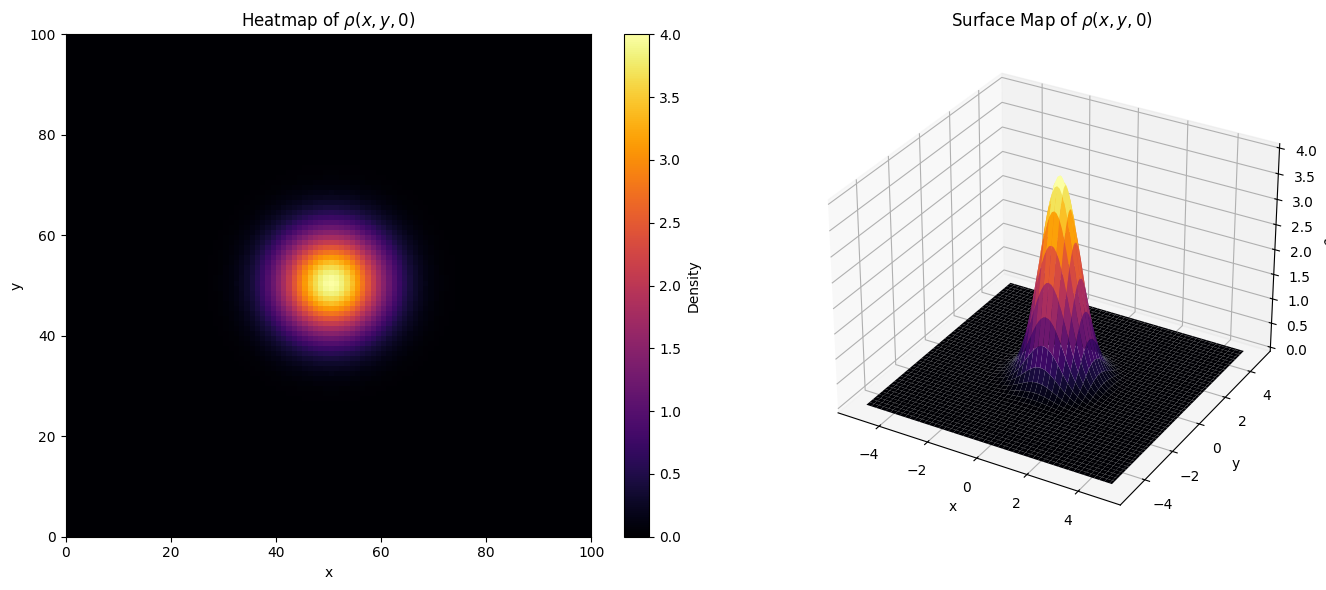

In [4]:
fig = plt.figure(figsize=(14, 6))
# Plot settings Heatmap
ax1 = fig.add_subplot(1, 2, 1)
heatmap = ax1.pcolormesh(fluid_solution.rho_o,cmap='inferno')
fig.colorbar(heatmap,label='Density')
ax1.set_title('Heatmap of $\\rho(x, y, 0)$')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
# Plot settings Surface
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surface = ax2.plot_surface(fluid_solution.x_2d, fluid_solution.y_2d, fluid_solution.rho_o, cmap='inferno')
ax2.set_title('Surface Map of $\\rho(x, y, 0)$')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('$\\rho$')
plt.tight_layout()
plt.show()


**(d)** Choose a reasonable value for the diffusion constant, $\alpha$, and call your function in (c). What is this function achieving so far and what space (real or Fourier) is the output in?

#### Reference: https://numpy.org/doc/2.1/reference/generated/numpy.iscomplex.html

In [5]:
# Test the rhs function
fluid_prob = FluidDynamics(nx=100, ny=100, L=10, alpha=0.05)
rhs_prob = fluid_prob.rhs_fluid(t=0, rho=fluid_prob.rho_o)
# Check shape, dtype and if the result is complex
#print(rhs_prob.shape)
#print(rhs_prob.dtype)
print(np.iscomplex(rhs_prob))

[False False False ... False False False]


#### The function implemented in subparagraph (c) is a Real output.


#### The Role of $\alpha$:

**(f)** Repeat the above calculations for two additional $\alpha$ values (one of them must be 0). Then, make a static figure with three panels comparing the 2D spatial distribution of the density at the final time step for each of the chosen $\alpha$ values.

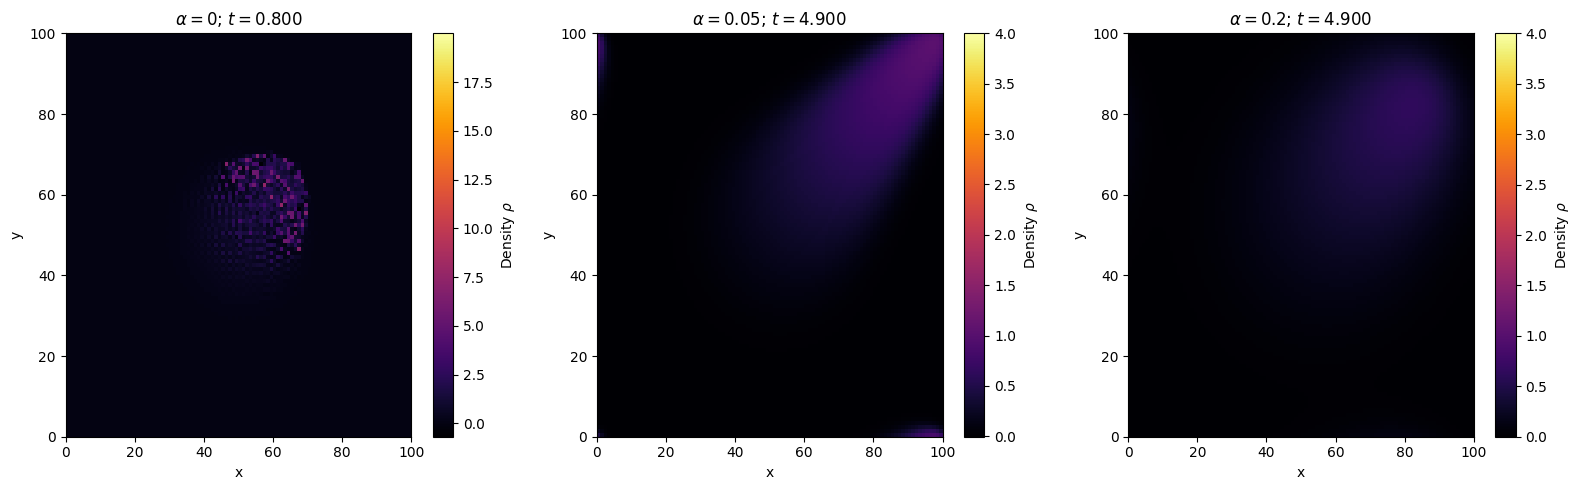

In [6]:
# List of alpha values to test
alpha_test = [0 , 0.05, 0.2]
# Create a dictionary to store the solutions 
solutions = {}
# Plot settings Heatmap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
# Loop over alpha values
for i, alpha in enumerate(alpha_test):
    # Call the class
    solutions[alpha] = FluidDynamics(nx=100, ny=100, L=10, alpha=alpha)    
    # Solve nonlinear PDE
    final_solution = solutions[alpha].scipy_integrate(t_max=5, dt=0.1)
    # Plot settings
    density_map = axes[i].pcolormesh(final_solution[-1], cmap='inferno',vmin=np.min(final_solution), vmax=np.max(final_solution))     
    axes[i].set_title(f'$\\alpha = {alpha}$; $t={solutions[alpha].t[-1]:.3f}$')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('y')       
    fig.colorbar(density_map, ax=axes[i], label="Density $\\rho$")
plt.tight_layout()
plt.show()

**(g)** Extract a 1D slice of your 2D solutions along the direction of propagation at the final time step. Create a single 1D line plot showing this profile for all three values of $\alpha$ to clearly illustrate the wave steepening and the role of $\alpha$

In [7]:
# Define parameters
L = 10
nx = 100
ny = 100
# Take index of the middle point
d = np.sqrt(L**2 + L**2)
# Create the 2D grid of the diagonal desplacement
propagation_diagonal = np.linspace(0, d, nx)

In [8]:
# Take 1 slice of the solution ICs, alpha 0, 0.05 and 0.2
# Define the index array of the diagonal
idx = np.arange(nx)
#print(idx)
# Take the diagonal slice of the solution at the last time step for each alpha
slice_alpha_0   = solutions[0].rho_t[-1, idx, idx]
slice_alpha_005 = solutions[0.05].rho_t[-1, idx, idx]
slice_alpha_02  = solutions[0.2].rho_t[-1, idx, idx]

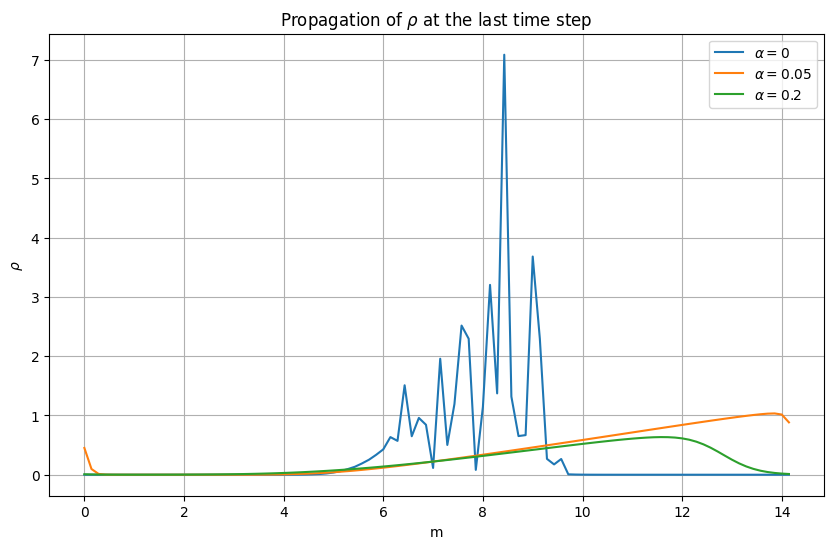

In [9]:
# Plot settings
plt.figure(figsize=(10, 6))
plt.plot(propagation_diagonal, slice_alpha_0, label='$\\alpha = 0$')
plt.plot(propagation_diagonal, slice_alpha_005, label='$\\alpha = 0.05$')
plt.plot(propagation_diagonal, slice_alpha_02, label='$\\alpha = 0.2$')
plt.title('Propagation of $\\rho$ at the last time step')
plt.xlabel('m')
plt.ylabel('$\\rho$')
plt.legend()
plt.grid()
plt.show()

**(h)** Write a method to generate animations for each of your three simulations showing the full temporal evolution of the 2D density profile from $t=0$ to your final time. 

In [10]:
# List of alpha values to test
alpha_test = [0 , 0.05, 0.2]
# Output folder for the animation frames
output_folder = '/home/tpaulcr/Documentos/FC2/fluid_gif'
# Loop over alpha values
for alpha in alpha_test:
    # Call the class
    solutions[alpha] = FluidDynamics(nx=100, ny=100, L=10, alpha=alpha)    
    # Solve nonlinear PDE
    final_solution = solutions[alpha].scipy_integrate(t_max=5, dt=0.1)
    # Create a specific folder for each alpha value
    output_folder_alpha = os.path.join(output_folder, f'alpha_{alpha}')
    # Create animation frames and GIF
    solutions[alpha].animation_frames(output_folder_alpha)

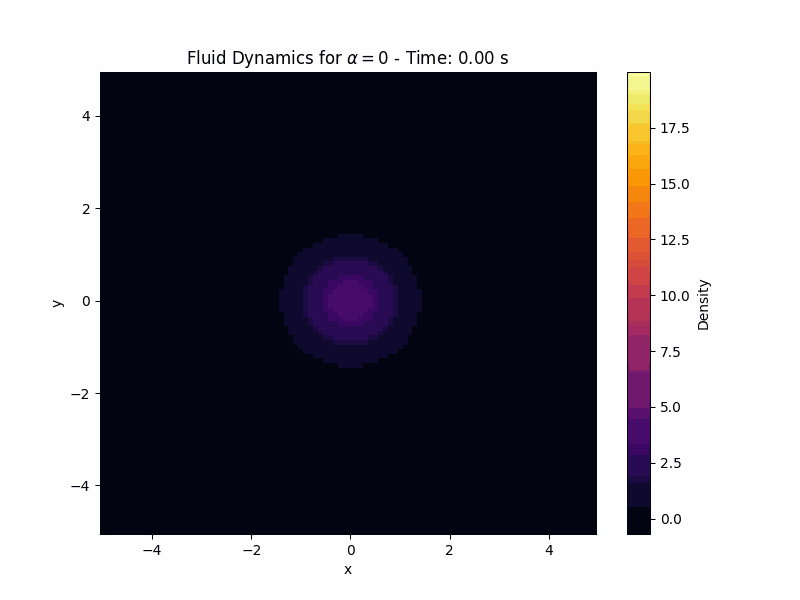

In [11]:
# Display the GIF for each alpha value
display(Img(filename='/home/tpaulcr/Documentos/FC2/fluid_gif/alpha_0/fluid_dynamics.gif'))

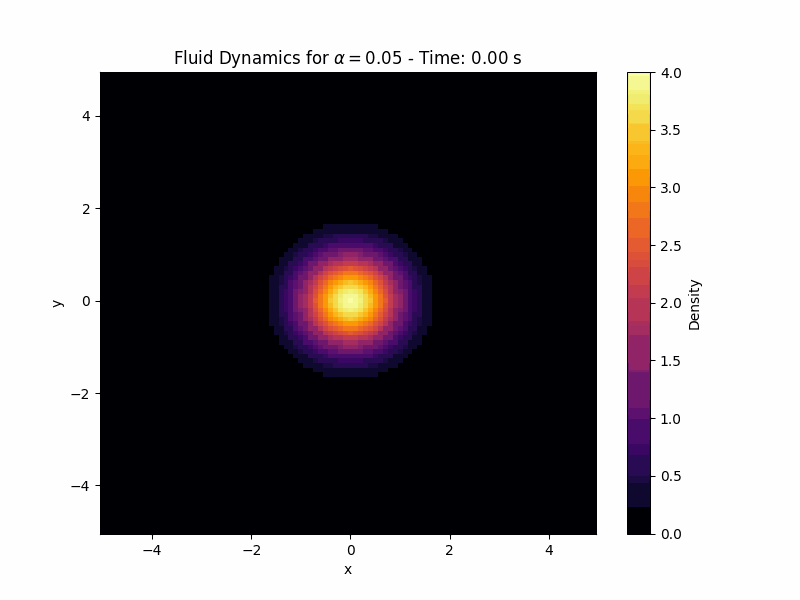

In [12]:
# Display the GIF for each alpha value
display(Img(filename='/home/tpaulcr/Documentos/FC2/fluid_gif/alpha_0.05/fluid_dynamics.gif'))

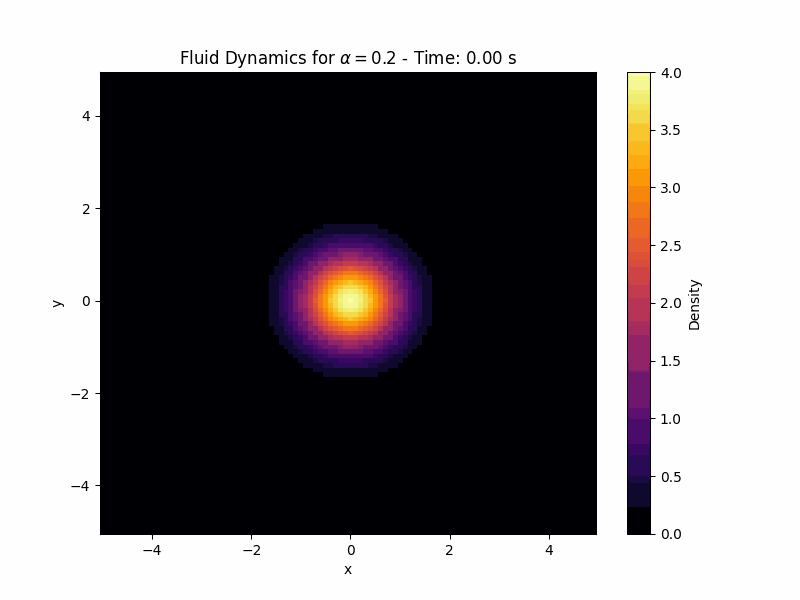

In [13]:
# Display the GIF for each alpha value
display(Img(filename='/home/tpaulcr/Documentos/FC2/fluid_gif/alpha_0.2/fluid_dynamics.gif'))

#### Analysis:

**(i)** Based on your 2D plots from (f), your 1D slices from (g), and your animations from (h), answer the following:

- In which direction does the shock wave propagate, and why?

It can be seen that the direction of propagation runs along both the x-axis and the y-axis, which means it is diagonally toward the upper-right corner. Consider that the reason for this may lie in how the density (ρ) is defined, since its equation shows that it depends on both the x and y variables, and therefore exhibits a rate of change in both directions.

- What is the role of the parameter $\alpha$ in regulating the physical morphology and numerical stability of the shock front? 

The diffusion constant plays a key role in controlling how the shock wave’s energy dissipates, as we have seen in the plots when testing different values of the diffusion constant: for an alpha value of 0, we obtain pure advection, while for an alpha value greater than 0, we observe that the shock wave’s effect is damped by shock front, causing its density to decrease over time. Depending on the value of alpha, we can better observe the damping effect it exerts on the shock wave: in the plot with alpha set to 0.05, diffusion allows a shock wave to form but, with alpha set to 0.2, diffusion more rapidly limits the energy exerted by the shock wave.



- What happens numerically and physically when $\alpha = 0$?

Numerically, what happens is that we eliminate the diffusion term from the PDE, which means we obtain pure advection. Physically, the shock wave does not dissipate energy,then the ρ gradient can grow indefinitely.